In [1]:
# ============================================================
# 10_nb_ml_forecasting.ipynb
# Machine Learning Forecasting
# ============================================================

# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src.config import DIR_DB_SILVER
from src.utils.m_query_database import f_query_database

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")


# ============================================================
# LOAD SILVER DATA
# ============================================================

query = 'SELECT * FROM "80072ned_silver"'

df = f_query_database(
    db_path=DIR_DB_SILVER,
    query=query,
    return_type="pandas"
)


# ============================================================
# TARGET CLEANING
# ============================================================

TARGET_COL = "Ziekteverzuimpercentage_1"

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)


# ============================================================
# CREATE TEMPORAL FEATURES
# ============================================================

df["frequency"] = np.select(
    [
        df["Perioden"].str.contains("KW", na=False),
        df["Perioden"].str.contains("MM", na=False),
        df["Perioden"].str.contains("JJ", na=False),
    ],
    [
        "quarterly",
        "monthly",
        "annual",
    ],
    default="unknown"
)

df["year"] = pd.to_numeric(
    df["Perioden"].str[:4],
    errors="coerce"
)

df["quarter"] = (
    df["Perioden"]
    .str.extract(r"KW(\d{2})")[0]
)

df["quarter"] = pd.to_numeric(
    df["quarter"],
    errors="coerce"
)


# ============================================================
# CREATE PERIOD END DATE
# ============================================================

df["period_enddate"] = pd.NaT

mask_q = df["frequency"] == "quarterly"

df.loc[mask_q, "period_enddate"] = (
    pd.PeriodIndex.from_fields(
        year=df.loc[mask_q, "year"].astype(int),
        quarter=df.loc[mask_q, "quarter"].astype(int),
        freq="Q"
    )
    .to_timestamp(how="end")
)

df["period_enddate"] = (
    pd.to_datetime(df["period_enddate"])
    .dt.normalize()
)


# ============================================================
# KEEP ONLY QUARTERLY OBSERVATIONS
# ============================================================

df = (
    df[df["frequency"] == "quarterly"]
    .copy()
)


# ============================================================
# KEEP ONLY PRIMARY SBI SECTORS
# ============================================================

primary_sector_mask = (
    df["BedrijfskenmerkenSBI2008_Title"]
    .str.match(r"^[A-S]\s")
)

df = (
    df[primary_sector_mask]
    .copy()
)


# ============================================================
# KEEP ONLY 2010+
# ============================================================

df = (
    df[
        df["period_enddate"] >= "2010-01-01"
    ]
    .copy()
)


# ============================================================
# FINAL MODELING DATAFRAME
# ============================================================

df_ml = (
    df[
        [
            "period_enddate",
            "year",
            "quarter",
            "BedrijfskenmerkenSBI2008_Title",
            TARGET_COL
        ]
    ]
    .copy()
)

df_ml = df_ml.rename(columns={
    "BedrijfskenmerkenSBI2008_Title": "sector",
    TARGET_COL: "absenteeism"
})

df_ml = df_ml.sort_values(
    [
        "sector",
        "period_enddate"
    ]
)

# ============================================================
# VALIDATION
# ============================================================

print(df_ml.shape)

display(df_ml.head())

✅ Query returned 5850 rows from silver_data.db as pandas DataFrame


(1216, 5)


,period_enddate,year,quarter,sector,absenteeism
220,2010-03-31,2010,1.0,"A Landbouw, bosbouw en visserij",2.5
221,2010-06-30,2010,2.0,"A Landbouw, bosbouw en visserij",2.6
222,2010-09-30,2010,3.0,"A Landbouw, bosbouw en visserij",2.4
223,2010-12-31,2010,4.0,"A Landbouw, bosbouw en visserij",2.8
225,2011-03-31,2011,1.0,"A Landbouw, bosbouw en visserij",3.3


In [2]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df_feat = df_ml.copy()


# ============================================================
# LAG FEATURES
# ============================================================

# Previous quarter
df_feat["lag_1"] = (
    df_feat
    .groupby("sector")["absenteeism"]
    .shift(1)
)

# Same quarter previous year
df_feat["lag_4"] = (
    df_feat
    .groupby("sector")["absenteeism"]
    .shift(4)
)

# Previous 2 quarters
df_feat["lag_2"] = (
    df_feat
    .groupby("sector")["absenteeism"]
    .shift(2)
)

# Previous 3 quarters
df_feat["lag_3"] = (
    df_feat
    .groupby("sector")["absenteeism"]
    .shift(3)
)


# ============================================================
# ROLLING FEATURES
# ============================================================

# Rolling mean (last 4 quarters)
df_feat["rolling_mean_4"] = (
    df_feat
    .groupby("sector")["absenteeism"]
    .transform(
        lambda x: x.shift(1).rolling(4).mean()
    )
)

# Rolling std deviation
df_feat["rolling_std_4"] = (
    df_feat
    .groupby("sector")["absenteeism"]
    .transform(
        lambda x: x.shift(1).rolling(4).std()
    )
)


# ============================================================
# TREND FEATURE
# ============================================================

# Sequential time index within sector
df_feat["time_index"] = (
    df_feat
    .groupby("sector")
    .cumcount()
)


# ============================================================
# FUTURE TARGET
# ============================================================

# Predict next quarter
df_feat["target"] = (
    df_feat
    .groupby("sector")["absenteeism"]
    .shift(-1)
)


# ============================================================
# REMOVE ROWS WITH NaNs
# ============================================================

df_feat = df_feat.dropna().reset_index(drop=True)


# ============================================================
# VALIDATION
# ============================================================

print(df_feat.shape)

display(df_feat.head())

(1121, 13)


,period_enddate,year,quarter,sector,absenteeism,lag_1,lag_4,lag_2,lag_3,rolling_mean_4,rolling_std_4,time_index,target
0,2011-03-31,2011,1.0,"A Landbouw, bosbouw en visserij",3.3,2.8,2.5,2.4,2.6,2.575,0.170783,4,2.7
1,2011-06-30,2011,2.0,"A Landbouw, bosbouw en visserij",2.7,3.3,2.6,2.8,2.4,2.775,0.386221,5,3.1
2,2011-09-30,2011,3.0,"A Landbouw, bosbouw en visserij",3.1,2.7,2.4,3.3,2.8,2.800,0.374166,6,3.1
3,2011-12-31,2011,4.0,"A Landbouw, bosbouw en visserij",3.1,3.1,2.8,2.7,3.3,2.975,0.275379,7,2.8
4,2012-03-31,2012,1.0,"A Landbouw, bosbouw en visserij",2.8,3.1,3.3,3.1,2.7,3.050,0.251661,8,2.8


In [3]:
# ============================================================
# ONE-HOT ENCODE SECTOR
# ============================================================

df_model = pd.get_dummies(
    df_feat,
    columns=["sector"],
    drop_first=True
)


# ============================================================
# DEFINE FEATURES
# ============================================================

FEATURES = [
    "year",
    "quarter",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "rolling_mean_4",
    "rolling_std_4",
    "time_index",
]

# Add encoded sector columns
sector_cols = [
    col for col in df_model.columns
    if col.startswith("sector_")
]

FEATURES.extend(sector_cols)


# ============================================================
# TARGET
# ============================================================

TARGET = "target"


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

# Train until end of 2022
train_df = (
    df_model[
        df_model["period_enddate"] < "2023-01-01"
    ]
    .copy()
)

# Test = 2023 onward
test_df = (
    df_model[
        df_model["period_enddate"] >= "2023-01-01"
    ]
    .copy()
)


# ============================================================
# CREATE X / y
# ============================================================

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]


# ============================================================
# VALIDATION
# ============================================================

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain period:")
print(train_df["period_enddate"].min())
print(train_df["period_enddate"].max())

print("\nTest period:")
print(test_df["period_enddate"].min())
print(test_df["period_enddate"].max())

Train shape: (912, 27)
Test shape: (209, 27)

Train period:
2011-03-31 00:00:00
2022-12-31 00:00:00

Test period:
2023-03-31 00:00:00
2025-09-30 00:00:00


In [4]:
# ============================================================
# TIME SERIES CROSS-VALIDATION — LINEAR REGRESSION
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

N_SPLITS = 5

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS
)

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

cv_results_lr = []

# ============================================================
# CROSS-VALIDATION LOOP
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(df_model),
    start=1
):

    print(f"\nFold {fold}")

    # --------------------------------------------------------
    # SPLIT
    # --------------------------------------------------------

    train_fold = df_model.iloc[train_idx]

    test_fold = df_model.iloc[test_idx]

    # --------------------------------------------------------
    # FEATURES / TARGET
    # --------------------------------------------------------

    X_train_cv = train_fold[FEATURES]
    y_train_cv = train_fold[TARGET]

    X_test_cv = test_fold[FEATURES]
    y_test_cv = test_fold[TARGET]

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model_lr_cv = LinearRegression()

    model_lr_cv.fit(
        X_train_cv,
        y_train_cv
    )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    pred_cv = model_lr_cv.predict(
        X_test_cv
    )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_test_cv,
        pred_cv
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_cv,
            pred_cv
        )
    )

    mape = np.mean(
        np.abs(
            (
                y_test_cv - pred_cv
            )
            / y_test_cv
        )
    ) * 100

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    cv_results_lr.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

# ============================================================
# RESULTS
# ============================================================

cv_results_lr = pd.DataFrame(
    cv_results_lr
)

cv_results_lr = cv_results_lr.round(3)

display(cv_results_lr)

# ============================================================
# AVERAGE PERFORMANCE
# ============================================================

summary_lr = (
    cv_results_lr[
        [
            "MAE",
            "RMSE",
            "MAPE"
        ]
    ]
    .mean()
    .to_frame()
    .T
)

summary_lr.insert(
    0,
    "Model",
    "Linear Regression CV"
)

summary_lr = summary_lr.round(3)

print("\nAVERAGE CV PERFORMANCE")

display(summary_lr)


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


,fold,MAE,RMSE,MAPE
0,1,0.524,0.675,10.574
1,2,0.440,0.574,10.409
2,3,0.214,0.272,6.550
3,4,0.521,0.639,10.338
4,5,0.523,0.688,10.339



AVERAGE CV PERFORMANCE


,Model,MAE,RMSE,MAPE
0,Linear Regression CV,0.444,0.57,9.642


In [5]:
# ============================================================
# RANDOM FOREST — TIME SERIES CV
# ============================================================

from sklearn.ensemble import RandomForestRegressor

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

N_SPLITS = 5

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS
)

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

cv_results_rf = []

# ============================================================
# CROSS-VALIDATION LOOP
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(df_model),
    start=1
):

    print(f"\nFold {fold}")

    # --------------------------------------------------------
    # SPLIT
    # --------------------------------------------------------

    train_fold = df_model.iloc[train_idx]

    test_fold = df_model.iloc[test_idx]

    # --------------------------------------------------------
    # FEATURES / TARGET
    # --------------------------------------------------------

    X_train_cv = train_fold[FEATURES]
    y_train_cv = train_fold[TARGET]

    X_test_cv = test_fold[FEATURES]
    y_test_cv = test_fold[TARGET]

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model_rf_cv = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model_rf_cv.fit(
        X_train_cv,
        y_train_cv
    )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    pred_cv = model_rf_cv.predict(
        X_test_cv
    )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_test_cv,
        pred_cv
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_cv,
            pred_cv
        )
    )

    mape = np.mean(
        np.abs(
            (
                y_test_cv - pred_cv
            )
            / y_test_cv
        )
    ) * 100

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    cv_results_rf.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

# ============================================================
# RESULTS
# ============================================================

cv_results_rf = pd.DataFrame(
    cv_results_rf
)

cv_results_rf = cv_results_rf.round(3)

display(cv_results_rf)

# ============================================================
# AVERAGE PERFORMANCE
# ============================================================

summary_rf = (
    cv_results_rf[
        [
            "MAE",
            "RMSE",
            "MAPE"
        ]
    ]
    .mean()
    .to_frame()
    .T
)

summary_rf.insert(
    0,
    "Model",
    "Random Forest CV"
)

summary_rf = summary_rf.round(3)

print("\nAVERAGE CV PERFORMANCE")

display(summary_rf)


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


,fold,MAE,RMSE,MAPE
0,1,0.360,0.445,7.999
1,2,0.293,0.401,8.735
2,3,0.239,0.287,7.578
3,4,0.231,0.317,4.872
4,5,0.308,0.455,6.124



AVERAGE CV PERFORMANCE


,Model,MAE,RMSE,MAPE
0,Random Forest CV,0.286,0.381,7.062


In [7]:
# ============================================================
# GRADIENT BOOSTING — TIME SERIES CV
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

N_SPLITS = 5

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS
)

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

cv_results_gb = []

# ============================================================
# CROSS-VALIDATION LOOP
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(df_model),
    start=1
):

    print(f"\nFold {fold}")

    # --------------------------------------------------------
    # SPLIT
    # --------------------------------------------------------

    train_fold = df_model.iloc[train_idx]

    test_fold = df_model.iloc[test_idx]

    # --------------------------------------------------------
    # FEATURES / TARGET
    # --------------------------------------------------------

    X_train_cv = train_fold[FEATURES]
    y_train_cv = train_fold[TARGET]

    X_test_cv = test_fold[FEATURES]
    y_test_cv = test_fold[TARGET]

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model_gb_cv = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model_gb_cv.fit(
        X_train_cv,
        y_train_cv
    )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    pred_cv = model_gb_cv.predict(
        X_test_cv
    )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_test_cv,
        pred_cv
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_cv,
            pred_cv
        )
    )

    mape = np.mean(
        np.abs(
            (
                y_test_cv - pred_cv
            )
            / y_test_cv
        )
    ) * 100

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    cv_results_gb.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

# ============================================================
# RESULTS
# ============================================================

cv_results_gb = pd.DataFrame(
    cv_results_gb
)

cv_results_gb = cv_results_gb.round(3)

display(cv_results_gb)

# ============================================================
# AVERAGE PERFORMANCE
# ============================================================

summary_gb = (
    cv_results_gb[
        [
            "MAE",
            "RMSE",
            "MAPE"
        ]
    ]
    .mean()
    .to_frame()
    .T
)

summary_gb.insert(
    0,
    "Model",
    "Gradient Boosting CV"
)

summary_gb = summary_gb.round(3)

print("\nAVERAGE CV PERFORMANCE")

display(summary_gb)


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


,fold,MAE,RMSE,MAPE
0,1,0.313,0.385,6.972
1,2,0.278,0.366,8.630
2,3,0.235,0.301,7.446
3,4,0.201,0.268,4.251
4,5,0.299,0.434,5.943



AVERAGE CV PERFORMANCE


,Model,MAE,RMSE,MAPE
0,Gradient Boosting CV,0.265,0.351,6.648


In [8]:
# ============================================================
# HISTOGRAM GRADIENT BOOSTING — TIME SERIES CV
# ============================================================

from sklearn.ensemble import HistGradientBoostingRegressor

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

N_SPLITS = 5

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS
)

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

cv_results_hgb = []

# ============================================================
# CROSS-VALIDATION LOOP
# ============================================================

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(df_model),
    start=1
):

    print(f"\nFold {fold}")

    # --------------------------------------------------------
    # SPLIT
    # --------------------------------------------------------

    train_fold = df_model.iloc[train_idx]

    test_fold = df_model.iloc[test_idx]

    # --------------------------------------------------------
    # FEATURES / TARGET
    # --------------------------------------------------------

    X_train_cv = train_fold[FEATURES]
    y_train_cv = train_fold[TARGET]

    X_test_cv = test_fold[FEATURES]
    y_test_cv = test_fold[TARGET]

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model_hgb_cv = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        min_samples_leaf=5,
        random_state=42
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model_hgb_cv.fit(
        X_train_cv,
        y_train_cv
    )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    pred_cv = model_hgb_cv.predict(
        X_test_cv
    )

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    mae = mean_absolute_error(
        y_test_cv,
        pred_cv
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_cv,
            pred_cv
        )
    )

    mape = np.mean(
        np.abs(
            (
                y_test_cv - pred_cv
            )
            / y_test_cv
        )
    ) * 100

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    cv_results_hgb.append({
        "fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

# ============================================================
# RESULTS
# ============================================================

cv_results_hgb = pd.DataFrame(
    cv_results_hgb
)

cv_results_hgb = cv_results_hgb.round(3)

display(cv_results_hgb)

# ============================================================
# AVERAGE PERFORMANCE
# ============================================================

summary_hgb = (
    cv_results_hgb[
        [
            "MAE",
            "RMSE",
            "MAPE"
        ]
    ]
    .mean()
    .to_frame()
    .T
)

summary_hgb.insert(
    0,
    "Model",
    "HistGradientBoosting CV"
)

summary_hgb = summary_hgb.round(3)

print("\nAVERAGE CV PERFORMANCE")

display(summary_hgb)


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5


,fold,MAE,RMSE,MAPE
0,1,0.374,0.446,8.521
1,2,0.274,0.369,8.289
2,3,0.255,0.323,8.009
3,4,0.211,0.271,4.543
4,5,0.308,0.450,6.149



AVERAGE CV PERFORMANCE


,Model,MAE,RMSE,MAPE
0,HistGradientBoosting CV,0.284,0.372,7.102


,feature,importance,importance_pct
0,rolling_mean_4,0.466,46.552
1,lag_3,0.433,43.270
2,time_index,0.030,2.965
3,quarter,0.022,2.156
4,lag_1,0.014,1.379
5,lag_2,0.013,1.326
6,rolling_std_4,0.012,1.241
7,lag_4,0.002,0.244
8,year,0.002,0.242
9,sector_I Horeca,0.002,0.157


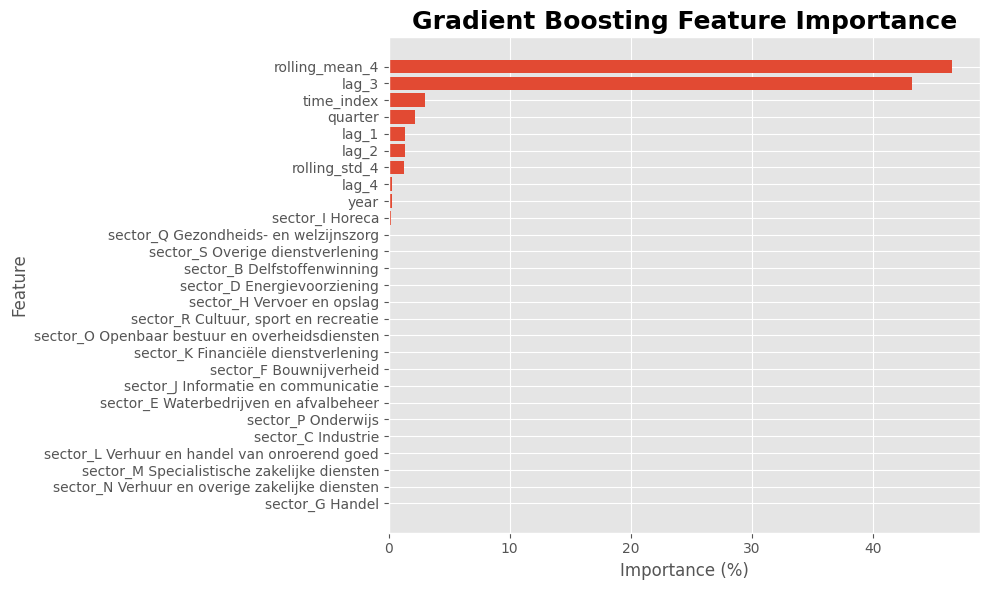

In [9]:
# ============================================================
# FINAL GRADIENT BOOSTING MODEL
# FEATURE IMPORTANCE ANALYSIS
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

# ------------------------------------------------------------
# FEATURES / TARGET
# ------------------------------------------------------------

X = df_model[FEATURES]

y = df_model[TARGET]

# ============================================================
# FINAL MODEL
# ============================================================

final_gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

final_gb_model.fit(
    X,
    y
)

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": final_gb_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df["importance_pct"] = (
    importance_df["importance"] * 100
)

importance_df = importance_df.round(3)

display(importance_df)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["feature"],
    importance_df["importance_pct"]
)

plt.gca().invert_yaxis()

plt.title(
    "Gradient Boosting Feature Importance",
    fontsize=18,
    weight="bold"
)

plt.xlabel(
    "Importance (%)",
    fontsize=12
)

plt.ylabel(
    "Feature",
    fontsize=12
)

plt.tight_layout()

plt.show()

In [12]:
df_feat.columns

Index(['period_enddate', 'year', 'quarter', 'sector', 'absenteeism', 'lag_1',
       'lag_4', 'lag_2', 'lag_3', 'rolling_mean_4', 'rolling_std_4',
       'time_index', 'target'],
      dtype='object')

In [14]:
df_feat["sector"].unique()

array(['A Landbouw, bosbouw en visserij', 'B Delfstoffenwinning',
       'C Industrie', 'D Energievoorziening',
       'E Waterbedrijven en afvalbeheer', 'F Bouwnijverheid', 'G Handel',
       'H Vervoer en opslag', 'I Horeca', 'J Informatie en communicatie',
       'K Financiële dienstverlening',
       'L Verhuur en handel van onroerend goed',
       'M Specialistische zakelijke diensten',
       'N Verhuur en overige zakelijke diensten',
       'O Openbaar bestuur en overheidsdiensten', 'P Onderwijs',
       'Q Gezondheids- en welzijnszorg', 'R Cultuur, sport en recreatie',
       'S Overige dienstverlening'], dtype=object)

In [13]:
selected_sectors = [
    "A-U Alle economische activiteiten",
    "Q Gezondheids- en welzijnszorg",
    "I Horeca",
    "K Financiële dienstverlening",
    "C Industrie",
    "P Onderwijs"
]

df_selected = (
    df_feat[
        df_feat["sector"].isin(selected_sectors)
    ]
    .copy()
)

print(df_selected.shape)

display(
    df_selected[
        ["sector"]
    ].drop_duplicates()
)

(295, 13)


,sector
118,C Industrie
472,I Horeca
590,K Financiële dienstverlening
885,P Onderwijs
944,Q Gezondheids- en welzijnszorg


In [15]:
# ============================================================
# LOCAL SECTOR MODELS — GRADIENT BOOSTING CV
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------

LOCAL_FEATURES = [
    "year",
    "quarter",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "rolling_mean_4",
    "rolling_std_4",
    "time_index"
]

TARGET = "target"

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

sector_results = []

# ============================================================
# LOOP THROUGH SECTORS
# ============================================================

for sector_name in df_selected["sector"].unique():

    print(f"\n========== {sector_name} ==========")

    # --------------------------------------------------------
    # FILTER SECTOR
    # --------------------------------------------------------

    df_sector = (
        df_selected[
            df_selected["sector"] == sector_name
        ]
        .sort_values("period_enddate")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # X / y
    # --------------------------------------------------------

    X = df_sector[LOCAL_FEATURES]

    y = df_sector[TARGET]

    # --------------------------------------------------------
    # CV
    # --------------------------------------------------------

    tscv = TimeSeriesSplit(
        n_splits=5
    )

    fold_metrics = []

    # ========================================================
    # CV LOOP
    # ========================================================

    for train_idx, test_idx in tscv.split(X):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # ----------------------------------------------------
        # MODEL
        # ----------------------------------------------------

        model = GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        )

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.fit(
            X_train,
            y_train
        )

        # ----------------------------------------------------
        # PREDICT
        # ----------------------------------------------------

        pred = model.predict(X_test)

        # ----------------------------------------------------
        # METRICS
        # ----------------------------------------------------

        mae = mean_absolute_error(
            y_test,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        )

        mape = np.mean(
            np.abs(
                (y_test - pred) / y_test
            )
        ) * 100

        fold_metrics.append(
            [mae, rmse, mape]
        )

    # --------------------------------------------------------
    # AVERAGE METRICS
    # --------------------------------------------------------

    fold_metrics = np.array(fold_metrics)

    sector_results.append({
        "sector": sector_name,
        "MAE": fold_metrics[:, 0].mean(),
        "RMSE": fold_metrics[:, 1].mean(),
        "MAPE": fold_metrics[:, 2].mean()
    })

# ============================================================
# RESULTS
# ============================================================

sector_results = pd.DataFrame(
    sector_results
)

sector_results = (
    sector_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

sector_results = sector_results.round(3)

display(sector_results)


========== C Industrie ==========

========== I Horeca ==========

========== K Financiële dienstverlening ==========

========== P Onderwijs ==========

========== Q Gezondheids- en welzijnszorg ==========


,sector,MAE,RMSE,MAPE
0,K Financiële dienstverlening,0.296,0.337,9.013
1,P Onderwijs,0.287,0.353,5.345
2,C Industrie,0.355,0.429,6.077
3,Q Gezondheids- en welzijnszorg,0.437,0.531,6.649
4,I Horeca,0.569,0.680,15.851



========== C Industrie ==========

========== I Horeca ==========

========== K Financiële dienstverlening ==========

========== P Onderwijs ==========

========== Q Gezondheids- en welzijnszorg ==========


,sector,feature,importance,importance_pct
4,C Industrie,lag_3,0.366,36.587
8,C Industrie,time_index,0.274,27.360
1,C Industrie,quarter,0.130,12.959
6,C Industrie,rolling_mean_4,0.106,10.589
7,C Industrie,rolling_std_4,0.051,5.121
0,C Industrie,year,0.024,2.408
2,C Industrie,lag_1,0.024,2.426
5,C Industrie,lag_4,0.016,1.564
3,C Industrie,lag_2,0.010,0.985
12,I Horeca,lag_2,0.375,37.490


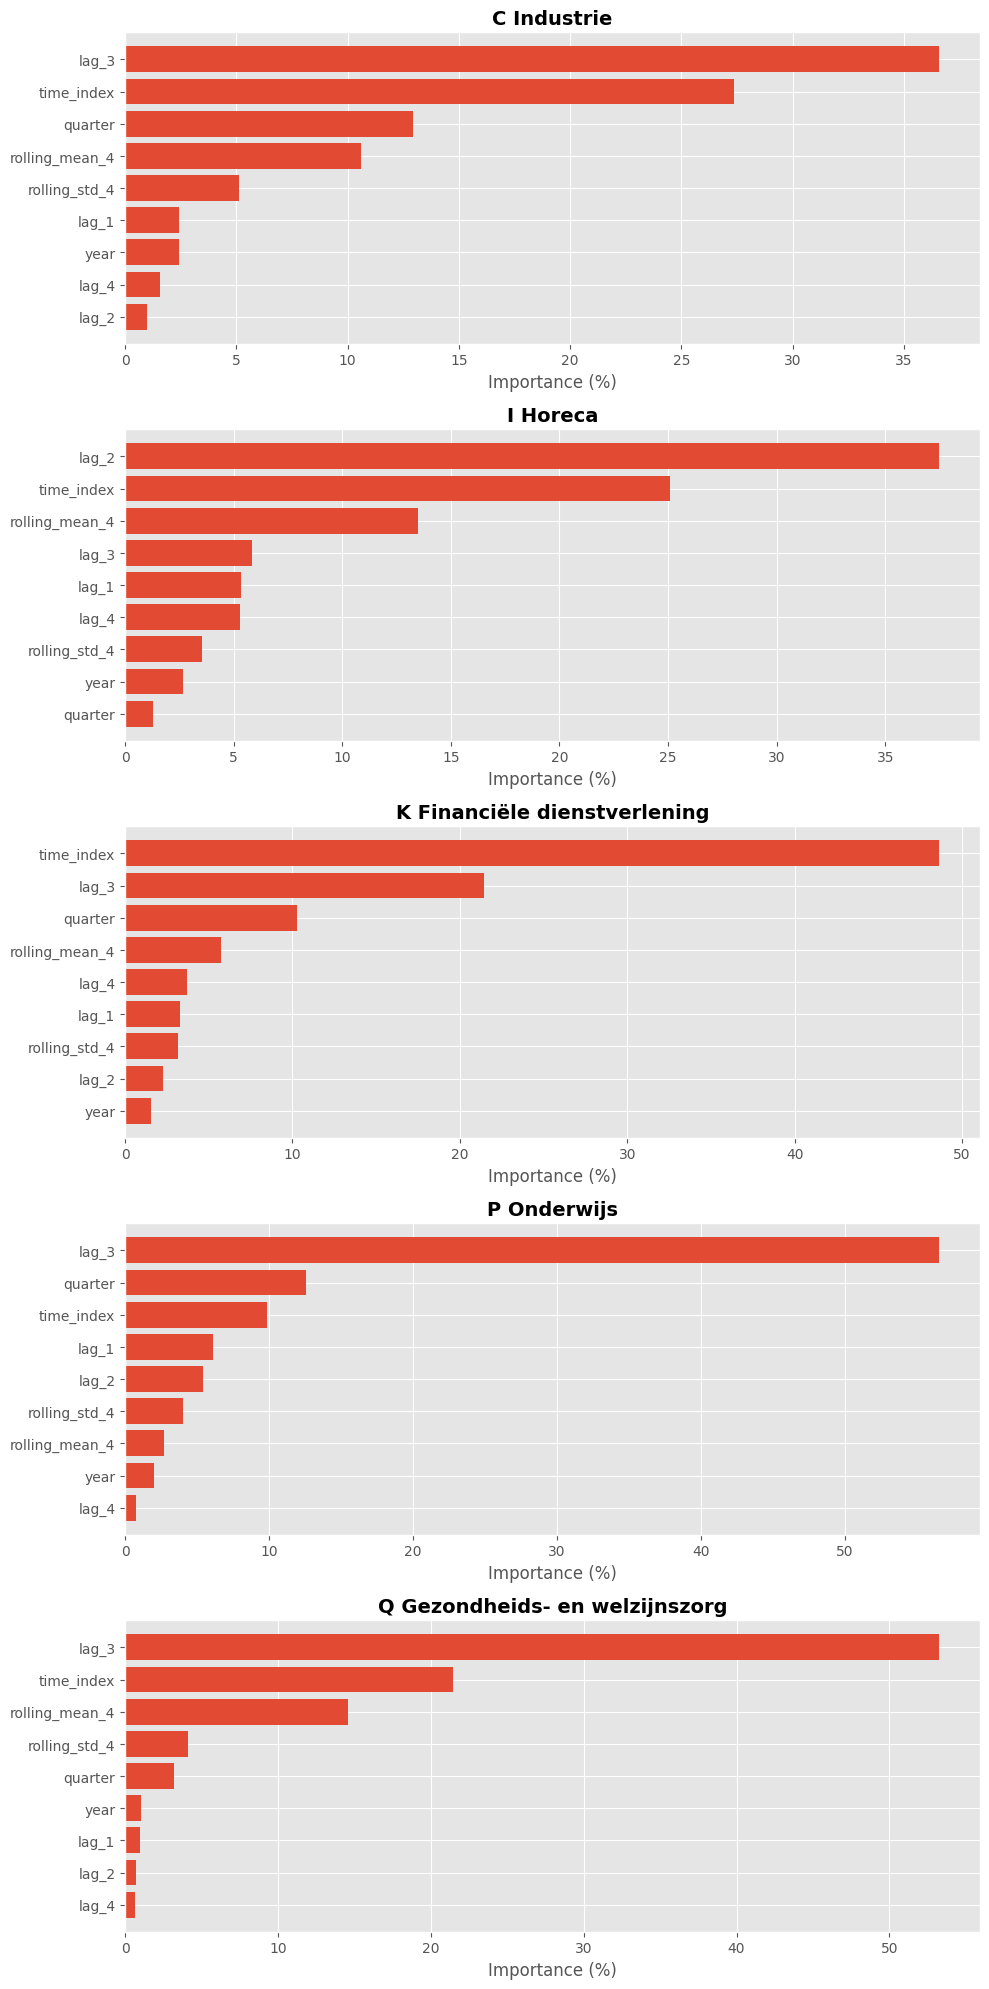

In [16]:
# ============================================================
# LOCAL MODEL FEATURE IMPORTANCE PER SECTOR
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

# ------------------------------------------------------------
# FEATURES
# ------------------------------------------------------------

LOCAL_FEATURES = [
    "year",
    "quarter",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "rolling_mean_4",
    "rolling_std_4",
    "time_index"
]

TARGET = "target"

# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

importance_all = []

# ============================================================
# LOOP THROUGH SECTORS
# ============================================================

for sector_name in df_selected["sector"].unique():

    print(f"\n========== {sector_name} ==========")

    # --------------------------------------------------------
    # FILTER SECTOR
    # --------------------------------------------------------

    df_sector = (
        df_selected[
            df_selected["sector"] == sector_name
        ]
        .sort_values("period_enddate")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # X / y
    # --------------------------------------------------------

    X = df_sector[LOCAL_FEATURES]

    y = df_sector[TARGET]

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.fit(X, y)

    # --------------------------------------------------------
    # FEATURE IMPORTANCE
    # --------------------------------------------------------

    importance_df = pd.DataFrame({
        "sector": sector_name,
        "feature": LOCAL_FEATURES,
        "importance": model.feature_importances_
    })

    importance_all.append(importance_df)

# ============================================================
# COMBINE RESULTS
# ============================================================

importance_all = pd.concat(
    importance_all,
    ignore_index=True
)

importance_all["importance_pct"] = (
    importance_all["importance"] * 100
)

importance_all = importance_all.round(3)

# ============================================================
# DISPLAY
# ============================================================

display(
    importance_all.sort_values(
        ["sector", "importance"],
        ascending=[True, False]
    )
)

# ============================================================
# PLOT
# ============================================================

sectors = importance_all["sector"].unique()

fig, axes = plt.subplots(
    nrows=len(sectors),
    ncols=1,
    figsize=(10, 4 * len(sectors))
)

if len(sectors) == 1:
    axes = [axes]

for ax, sector_name in zip(axes, sectors):

    plot_df = (
        importance_all[
            importance_all["sector"] == sector_name
        ]
        .sort_values(
            "importance_pct",
            ascending=False
        )
    )

    ax.barh(
        plot_df["feature"],
        plot_df["importance_pct"]
    )

    ax.invert_yaxis()

    ax.set_title(
        sector_name,
        fontsize=14,
        weight="bold"
    )

    ax.set_xlabel("Importance (%)")

plt.tight_layout()

plt.show()

# Machine Learning Forecasting — Summary of Work and Key Findings

## Objective

The objective of this notebook was to explore whether machine learning (ML) approaches could improve quarterly absenteeism forecasting compared to classical time-series methods.

The analysis focused on predicting quarterly absenteeism percentages for Dutch economic sectors using historical CBS absenteeism data from 2010–2025.

The notebook investigated:
- global pooled ML models,
- local sector-specific ML models,
- temporal feature engineering,
- feature importance analysis,
- and time-aware validation strategies.

---

# 1. Dataset Preparation

## Selected Data

The analysis used:
- quarterly absenteeism observations,
- 19 major Dutch sectors (A–S),
- data from 2010 Q1 to 2025 Q4.

The 2010 starting point was selected because:
- all sectors contained complete observations,
- no missing values remained,
- and sector histories became fully consistent.

This resulted in:
- 64 quarterly observations per sector,
- 1216 total observations across all sectors.

---

# 2. Feature Engineering

To transform the forecasting problem into a supervised ML problem, several temporal features were created.

## Temporal Features

### Calendar Features
- `year`
- `quarter`
- `time_index`

### Lag Features
Historical absenteeism values:
- `lag_1`
- `lag_2`
- `lag_3`
- `lag_4`

These represent absenteeism levels from previous quarters.

### Rolling Features
Short-term historical behavior:
- `rolling_mean_4`
- `rolling_std_4`

These capture:
- recent absenteeism level,
- recent volatility.

---

# 3. Global ML Modeling

## Modeling Strategy

A global pooled modeling strategy was used:
- all sectors combined into one training dataset,
- sector identity encoded using one-hot encoding,
- one ML model trained across all sectors.

This approach allowed the model to:
- learn shared temporal patterns,
- leverage more training observations,
- and improve robustness.

---

# 4. Validation Methodology

## Time-Aware Cross-Validation

Standard random train-test splitting was avoided because:
- forecasting problems require chronological ordering,
- future observations must never leak into training data.

Instead, the notebook used:

## TimeSeriesSplit (Rolling Cross-Validation)

For each fold:
- earlier quarters were used for training,
- later unseen quarters were used for validation.

This simulated real forecasting deployment conditions.

Five rolling validation folds were used.

---

# 5. ML Models Evaluated

The following ML models were tested:

## Linear Regression
Baseline linear forecasting model.

## Random Forest Regressor
Nonlinear ensemble model using bagging.

## Gradient Boosting Regressor
Sequential boosting-based ensemble model.

## HistGradientBoosting Regressor
Histogram-optimized gradient boosting model.

---

# 6. Global ML Results

## Average Cross-Validation Performance

| Model | RMSE | MAPE |
|---|---|---|
| Linear Regression | ~0.57 | ~9.6% |
| Random Forest | ~0.38 | ~7.1% |
| Gradient Boosting | ~0.35 | ~6.7% |
| HistGradientBoosting | ~0.37 | ~7.1% |

## Main Findings

### Nonlinear ML models substantially outperformed linear regression.

This indicates absenteeism dynamics contain:
- nonlinear relationships,
- temporal dependencies,
- and sector-specific interactions.

### Gradient Boosting was the strongest ML model.

Gradient Boosting achieved:
- the lowest forecasting errors,
- the best stability across validation folds,
- and the strongest overall ML performance.

### However, SARIMA still outperformed all ML models.

Compared with earlier classical time-series experiments:
- recursive SARIMA forecasting remained the best overall forecasting strategy.

This suggests absenteeism forecasting is still dominated by:
- autoregressive temporal structure,
- seasonality,
- and recurring historical patterns.

---

# 7. Feature Importance Analysis

Feature importance analysis was performed using the final Gradient Boosting model.

## Most Important Features

| Feature | Approximate Importance |
|---|---|
| `rolling_mean_4` | ~47% |
| `lag_3` | ~43% |

Together, these features explained approximately 90% of total predictive importance.

---

# 8. Interpretation of Feature Importance

## Temporal Memory Dominates Forecasting

The results showed that:
- recent absenteeism history is the strongest predictor of future absenteeism,
- absenteeism patterns contain strong temporal memory,
- and medium-term historical structure matters more than short-term fluctuations.

## Lag-3 Importance

The strong importance of `lag_3` indicates:
- absenteeism from several quarters earlier strongly helps predict future absenteeism,
- recurring medium-term patterns exist,
- and quarterly seasonality plays a major role.

## Quarter More Important Than Year

`quarter` contributed more predictive power than `year`, indicating:
- seasonality is stronger than long-term trend effects.

## Sector Identity Contributed Little Globally

Sector dummy variables had very low importance.

This suggests:
- sectors share substantial common temporal structure,
- and most predictive signal comes from historical absenteeism itself.

---

# 9. Local Sector-Specific ML Models

To test whether sectors behave differently internally, separate local Gradient Boosting models were trained for selected sectors:
- Industry,
- Horeca,
- Finance,
- Education,
- Healthcare.

## Main Findings

### Local models generally did not outperform the global pooled model.

Possible reasons:
- limited observations per sector,
- reduced training size,
- and shared temporal structure across sectors.

### Sector forecasting difficulty varied strongly.

Examples:
- Finance was easiest to forecast,
- Horeca was hardest to forecast.

---

# 10. Local Feature Importance Findings

Although global sector identity contributed little predictive power, local sector analysis revealed important differences in temporal dynamics.

Examples:

## Finance
- strongly trend-driven,
- `time_index` dominant.

## Education
- highly seasonal,
- `lag_3` and `quarter` dominant.

## Horeca
- volatile and unstable,
- weaker seasonal structure,
- stronger sensitivity to structural shifts.

This demonstrated that:
- sectors share common forecasting structure globally,
- but individual sectors rely on different temporal mechanisms internally.

---

# 11. Overall ML Conclusions

## Key Conclusions

### 1.
Absenteeism forecasting is highly autoregressive and seasonal.

### 2.
Recent historical absenteeism is the strongest predictor of future absenteeism.

### 3.
Nonlinear ML models outperform linear ML approaches.

### 4.
Gradient Boosting was the strongest ML model tested.

### 5.
Classical recursive SARIMA forecasting still achieved the best overall forecasting accuracy.

### 6.
Global pooled ML models were generally more robust than local sector-specific ML models.

### 7.
Sector identity adds relatively limited predictive value globally.

### 8.
However, sectors differ internally in how temporal dynamics operate.

---

# 12. Next Recommended Step

The next logical extension is:
## multivariate forecasting using external features.

Potential future predictors include:
- labor market indicators,
- unemployment,
- inflation,
- demographic structure,
- economic activity,
- healthcare pressure indicators.

This may allow ML models to:
- capture causal drivers of absenteeism,
- improve forecasting performance,
- and potentially outperform purely autoregressive statistical models.